For each of the 3 task variants, we generated 10 sequences using a MILP solver that should get all the conditions right. This notebook verifies that all our conditions are satisifed.

In [6]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, os, glob, json

In [8]:
############# Helper functions #############
# sequences are stored in .js files, we need to read them in as JSON
def read_sequences_js(path):
    with open(path) as f:
        content = f.read()
    content = content.replace('window.SEQUENCE_STRUCTURES = ', '', 1).rstrip().rstrip(';')
    return json.loads(content)

# correct counts of old and new trials
def check_old_new(df, task):
    n = len(df)
    n_old = df.trial_type.value_counts()['old']
    p = n_old / n
    n_old_correct = 156 if task=='task' else 78
    symbol = '✓' if n_old == n_old_correct else 'X'
    print(f'    Old trials: {n_old}/{n} ({p:.0%}) {symbol}')

# correct counts of old trials across conditions
def check_old_conditions(df, task):
    if task == 'task-mixed':
        mem = df.query('trial_type == "old"').groupby(['retrieval_type']).size().values
        symbol = '✓' if (mem == [20,20,19,19]).all() else 'X'
        print(f'    Balanced old trials across conditions: {symbol}')
    else:
        mem = df.query('trial_type == "old"').groupby(['memorability_bin']).size().values
        symbol = '✓' if (mem == mem[0]).all() else 'X'
        print(f'    Balanced old trials across memorability bins: {symbol}')

# values balanced on new & old trials
def check_values(df, task):
    new = df.query('trial_type == "new"').groupby(['memorability_bin','shared_value']).size().values
    symbol = '✓' if (new == new[0]).all() else 'X'
    print(f'    Balanced values on NEW trials across memorability bins: {symbol}')

    if task == 'task':
        old = df.query('trial_type == "old"').groupby(['memorability_bin','old_card_value']).size().values
        symbol = '✓' if (old == old[0]).all() else 'X'
        print(f'    Balanced values on OLD trials across memorability bins: {symbol}')

# delays matched on old trials
def check_delays(df, task):
    if task == 'task':
        # how often does each delay appear, for each memorability bin and value
        delay_df = df.query('trial_type == "old"').groupby(['memorability_bin','old_card_value'])['delay'].value_counts().unstack(fill_value=0)
        # check the counts are equal across all conditions
        symbol = '✓' if (delay_df.nunique() == 1).all() else 'X'
        print(f'    Same delays across memorability bins & old card values: {symbol}')
    
    elif task == 'task-mixed':
        old = df[df["trial_type"] == "old"]

        # even trials: high-mem and low-mem should have the same delays
        even = old[old["retrieval_type"].isin(["even_1", "even_0"])]
        delay_high_even = even["delay_high"].value_counts().sort_index()
        delay_low_even = even["delay_low"].value_counts().sort_index()
        even_symbol = '✓' if delay_high_even.equals(delay_low_even) else 'X'
        print(f'    Even trials — same delays for high vs low mem: {even_symbol}')

        # uneven trials: high-mem/low-mem AND $1/$0 should all have the same delays
        uneven = old[old["retrieval_type"].isin(["uneven_h1", "uneven_h0"])].copy()
        uneven["delay_v1"] = np.where(uneven["value_high"] == 1, uneven["delay_high"], uneven["delay_low"])
        uneven["delay_v0"] = np.where(uneven["value_high"] == 0, uneven["delay_high"], uneven["delay_low"])

        all_groups = pd.concat([uneven["delay_high"].value_counts(),uneven["delay_low"].value_counts(),uneven["delay_v1"].value_counts(),uneven["delay_v0"].value_counts()], axis=1).fillna(0)
        uneven_symbol = '✓' if (all_groups.nunique(axis=1) == 1).all() else 'X'
        print(f'    Uneven trials — same delays for high/low mem & $1/$0: {uneven_symbol}')

    elif task == 'task-matched':
        old = df[df["trial_type"] == "old"]

        old = df[df["trial_type"] == "old"]
        # first check the delays of the $1 items - matched across memorability?
        delay_v1 = old.groupby("memorability_bin")["delay_value1"].value_counts().unstack(fill_value=0)
        # now check the delays of the $0 items - matched across memorability?
        delay_v0 = old.groupby("memorability_bin")["delay_value0"].value_counts().unstack(fill_value=0)
        # concatenate to check that the delays match across memorability and value
        all_groups = pd.concat([delay_v1, delay_v0])  # 4 rows: high_v1, low_v1, high_v0, low_v0
        symbol = '✓' if (all_groups.nunique() == 1).all() else 'X'
        print(f'    Same delays across memorability bins & old card values: {symbol}')

# random-looking sequences of old/new trials, and memorability bins
def plot_sequences(df, task):
    type_colors = {'new': 'tab:orange', 'old': 'tab:blue'}
    bin_colors = {'high': 'tab:red', 'mid': 'tab:purple', 'low': 'tab:cyan', 'nan': 'black'}

    fig, axes = plt.subplots(2, 1, figsize=(8, 1.6), sharex=True)

    axes[0].set_title('Trial types - orange=new, blue=old', fontsize=10)
    axes[0].scatter(df['trial_number'], [0] * len(df), c=df['trial_type'].map(type_colors), marker='|', s=300)

    axes[1].set_title('Memorability bins - red=high, purple=mid, cyan=low, black=mixed', fontsize=10)
    axes[1].scatter(df['trial_number'], [0] * len(df), c=df['memorability_bin'].fillna('nan').map(bin_colors), marker='|', s=300)

    for ax in axes:
        ax.set_yticks([])
        ax.set_xticks([])
    plt.tight_layout()
    plt.show()



================== Task: task ================== 
sequence/seed 0
    Old trials: 156/312 (50%) ✓
    Balanced old trials across memorability bins: ✓
    Balanced values on NEW trials across memorability bins: ✓
    Balanced values on OLD trials across memorability bins: ✓
    Same delays across memorability bins & old card values: ✓


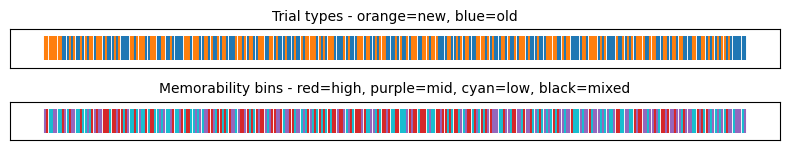

sequence/seed 1
    Old trials: 156/312 (50%) ✓
    Balanced old trials across memorability bins: ✓
    Balanced values on NEW trials across memorability bins: ✓
    Balanced values on OLD trials across memorability bins: ✓
    Same delays across memorability bins & old card values: ✓


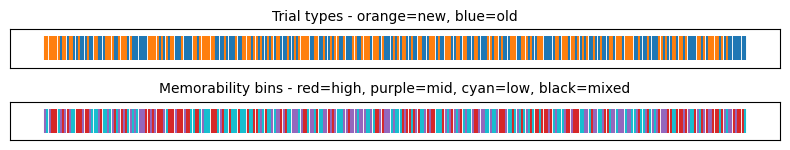

sequence/seed 2
    Old trials: 156/312 (50%) ✓
    Balanced old trials across memorability bins: ✓
    Balanced values on NEW trials across memorability bins: ✓
    Balanced values on OLD trials across memorability bins: ✓
    Same delays across memorability bins & old card values: ✓


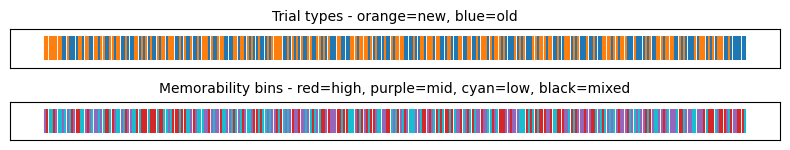

sequence/seed 3
    Old trials: 156/312 (50%) ✓
    Balanced old trials across memorability bins: ✓
    Balanced values on NEW trials across memorability bins: ✓
    Balanced values on OLD trials across memorability bins: ✓
    Same delays across memorability bins & old card values: ✓


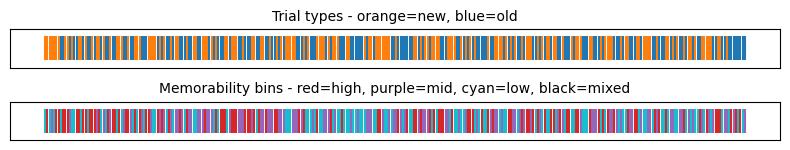

sequence/seed 4
    Old trials: 156/312 (50%) ✓
    Balanced old trials across memorability bins: ✓
    Balanced values on NEW trials across memorability bins: ✓
    Balanced values on OLD trials across memorability bins: ✓
    Same delays across memorability bins & old card values: ✓


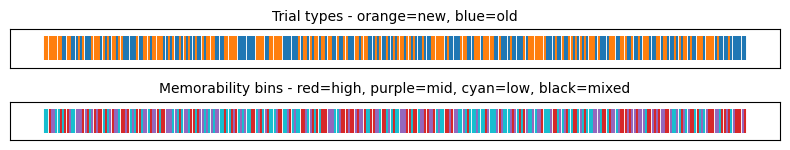

sequence/seed 5
    Old trials: 156/312 (50%) ✓
    Balanced old trials across memorability bins: ✓
    Balanced values on NEW trials across memorability bins: ✓
    Balanced values on OLD trials across memorability bins: ✓
    Same delays across memorability bins & old card values: ✓


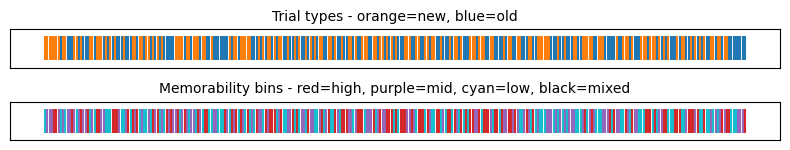

sequence/seed 6
    Old trials: 156/312 (50%) ✓
    Balanced old trials across memorability bins: ✓
    Balanced values on NEW trials across memorability bins: ✓
    Balanced values on OLD trials across memorability bins: ✓
    Same delays across memorability bins & old card values: ✓


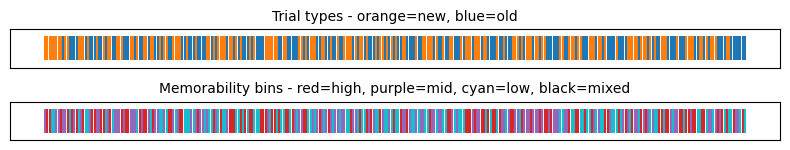

sequence/seed 7
    Old trials: 156/312 (50%) ✓
    Balanced old trials across memorability bins: ✓
    Balanced values on NEW trials across memorability bins: ✓
    Balanced values on OLD trials across memorability bins: ✓
    Same delays across memorability bins & old card values: ✓


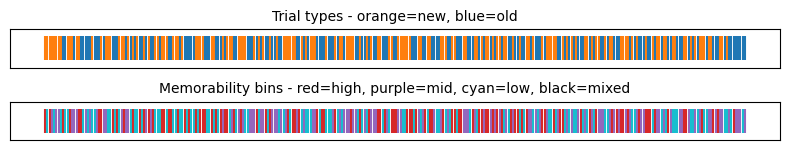

sequence/seed 8
    Old trials: 156/312 (50%) ✓
    Balanced old trials across memorability bins: ✓
    Balanced values on NEW trials across memorability bins: ✓
    Balanced values on OLD trials across memorability bins: ✓
    Same delays across memorability bins & old card values: ✓


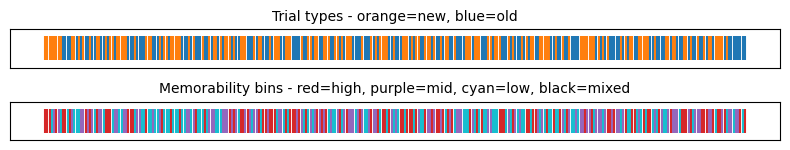

sequence/seed 9
    Old trials: 156/312 (50%) ✓
    Balanced old trials across memorability bins: ✓
    Balanced values on NEW trials across memorability bins: ✓
    Balanced values on OLD trials across memorability bins: ✓
    Same delays across memorability bins & old card values: ✓


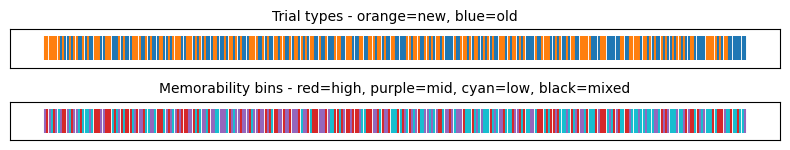


================== Task: task-mixed ================== 
sequence/seed 0
    Old trials: 78/234 (33%) ✓
    Balanced old trials across conditions: ✓
    Balanced values on NEW trials across memorability bins: ✓
    Even trials — same delays for high vs low mem: ✓
    Uneven trials — same delays for high/low mem & $1/$0: ✓


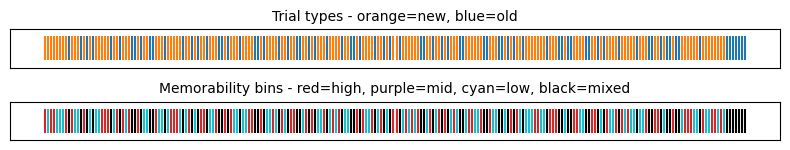

sequence/seed 1
    Old trials: 78/234 (33%) ✓
    Balanced old trials across conditions: ✓
    Balanced values on NEW trials across memorability bins: ✓
    Even trials — same delays for high vs low mem: ✓
    Uneven trials — same delays for high/low mem & $1/$0: ✓


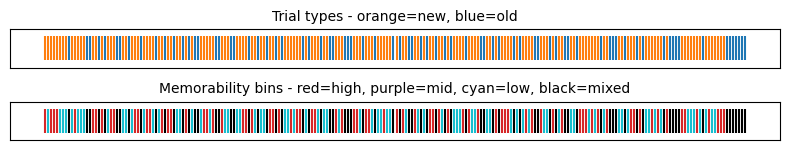

sequence/seed 2
    Old trials: 78/234 (33%) ✓
    Balanced old trials across conditions: ✓
    Balanced values on NEW trials across memorability bins: ✓
    Even trials — same delays for high vs low mem: ✓
    Uneven trials — same delays for high/low mem & $1/$0: ✓


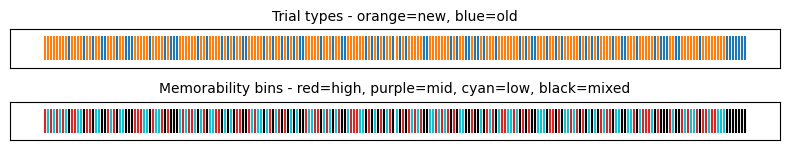

sequence/seed 3
    Old trials: 78/234 (33%) ✓
    Balanced old trials across conditions: ✓
    Balanced values on NEW trials across memorability bins: ✓
    Even trials — same delays for high vs low mem: ✓
    Uneven trials — same delays for high/low mem & $1/$0: ✓


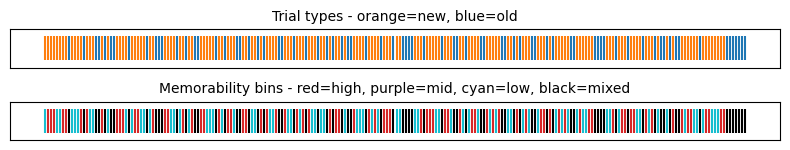

sequence/seed 4
    Old trials: 78/234 (33%) ✓
    Balanced old trials across conditions: ✓
    Balanced values on NEW trials across memorability bins: ✓
    Even trials — same delays for high vs low mem: ✓
    Uneven trials — same delays for high/low mem & $1/$0: ✓


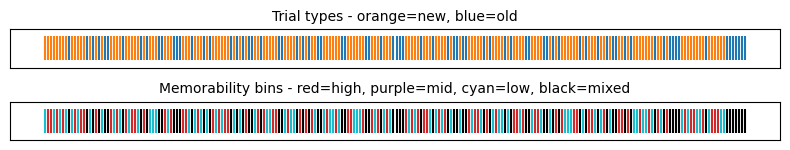

sequence/seed 5
    Old trials: 78/234 (33%) ✓
    Balanced old trials across conditions: ✓
    Balanced values on NEW trials across memorability bins: ✓
    Even trials — same delays for high vs low mem: ✓
    Uneven trials — same delays for high/low mem & $1/$0: ✓


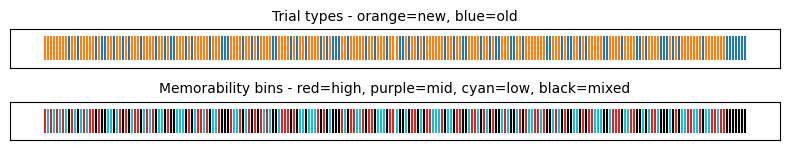

sequence/seed 6
    Old trials: 78/234 (33%) ✓
    Balanced old trials across conditions: ✓
    Balanced values on NEW trials across memorability bins: ✓
    Even trials — same delays for high vs low mem: ✓
    Uneven trials — same delays for high/low mem & $1/$0: ✓


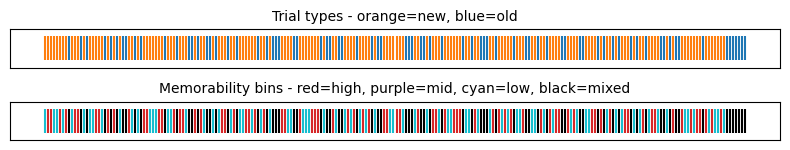

sequence/seed 7
    Old trials: 78/234 (33%) ✓
    Balanced old trials across conditions: ✓
    Balanced values on NEW trials across memorability bins: ✓
    Even trials — same delays for high vs low mem: ✓
    Uneven trials — same delays for high/low mem & $1/$0: ✓


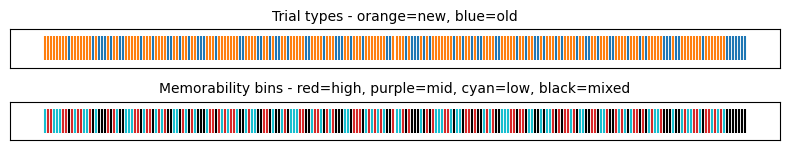

sequence/seed 8
    Old trials: 78/234 (33%) ✓
    Balanced old trials across conditions: ✓
    Balanced values on NEW trials across memorability bins: ✓
    Even trials — same delays for high vs low mem: ✓
    Uneven trials — same delays for high/low mem & $1/$0: ✓


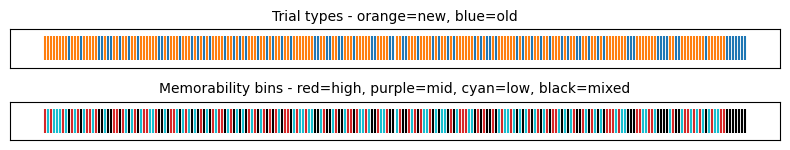

sequence/seed 9
    Old trials: 78/234 (33%) ✓
    Balanced old trials across conditions: ✓
    Balanced values on NEW trials across memorability bins: ✓
    Even trials — same delays for high vs low mem: ✓
    Uneven trials — same delays for high/low mem & $1/$0: ✓


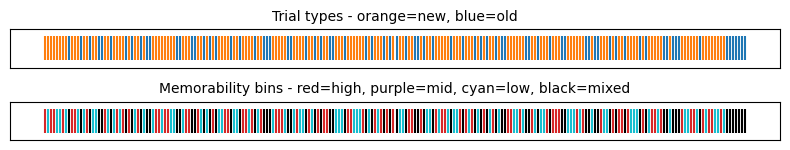


================== Task: task-matched ================== 
sequence/seed 0
    Old trials: 78/234 (33%) ✓
    Balanced old trials across memorability bins: ✓
    Balanced values on NEW trials across memorability bins: ✓
    Same delays across memorability bins & old card values: ✓


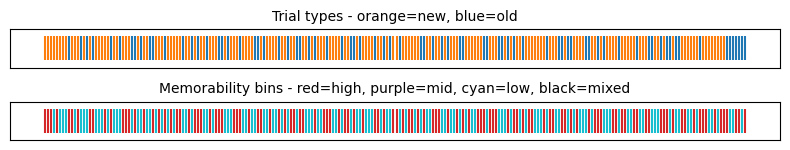

sequence/seed 1
    Old trials: 78/234 (33%) ✓
    Balanced old trials across memorability bins: ✓
    Balanced values on NEW trials across memorability bins: ✓
    Same delays across memorability bins & old card values: ✓


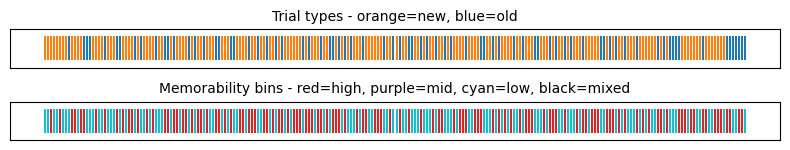

sequence/seed 2
    Old trials: 78/234 (33%) ✓
    Balanced old trials across memorability bins: ✓
    Balanced values on NEW trials across memorability bins: ✓
    Same delays across memorability bins & old card values: ✓


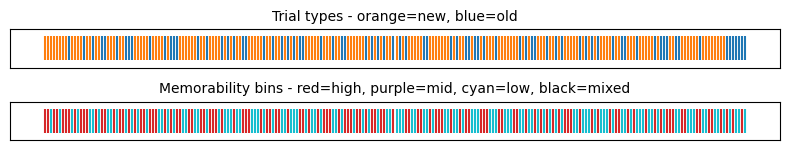

sequence/seed 3
    Old trials: 78/234 (33%) ✓
    Balanced old trials across memorability bins: ✓
    Balanced values on NEW trials across memorability bins: ✓
    Same delays across memorability bins & old card values: ✓


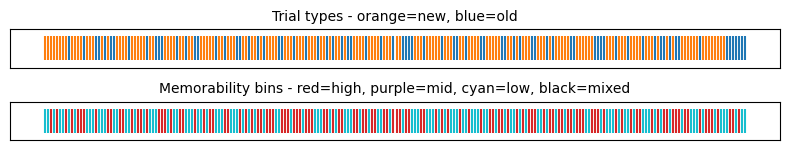

sequence/seed 4
    Old trials: 78/234 (33%) ✓
    Balanced old trials across memorability bins: ✓
    Balanced values on NEW trials across memorability bins: ✓
    Same delays across memorability bins & old card values: ✓


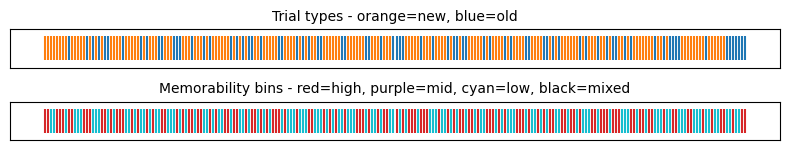

sequence/seed 5
    Old trials: 78/234 (33%) ✓
    Balanced old trials across memorability bins: ✓
    Balanced values on NEW trials across memorability bins: ✓
    Same delays across memorability bins & old card values: ✓


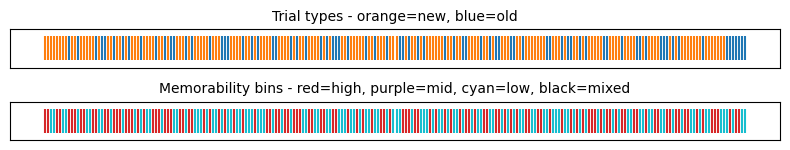

sequence/seed 6
    Old trials: 78/234 (33%) ✓
    Balanced old trials across memorability bins: ✓
    Balanced values on NEW trials across memorability bins: ✓
    Same delays across memorability bins & old card values: ✓


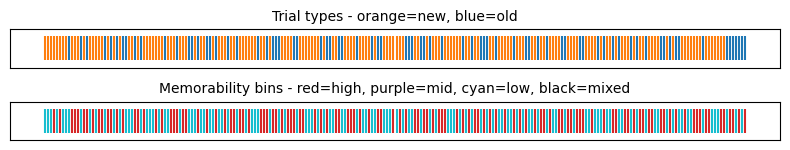

sequence/seed 7
    Old trials: 78/234 (33%) ✓
    Balanced old trials across memorability bins: ✓
    Balanced values on NEW trials across memorability bins: ✓
    Same delays across memorability bins & old card values: ✓


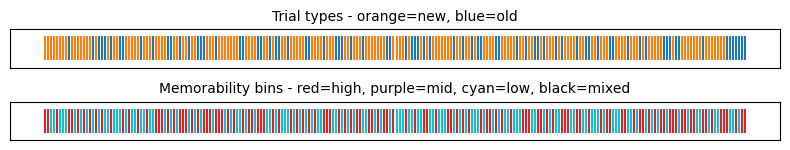

sequence/seed 8
    Old trials: 78/234 (33%) ✓
    Balanced old trials across memorability bins: ✓
    Balanced values on NEW trials across memorability bins: ✓
    Same delays across memorability bins & old card values: ✓


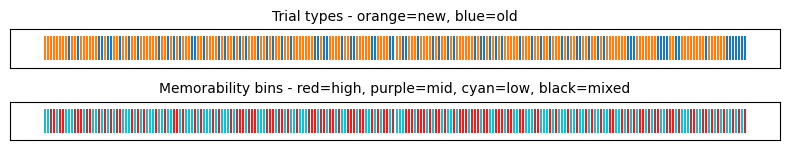

sequence/seed 9
    Old trials: 78/234 (33%) ✓
    Balanced old trials across memorability bins: ✓
    Balanced values on NEW trials across memorability bins: ✓
    Same delays across memorability bins & old card values: ✓


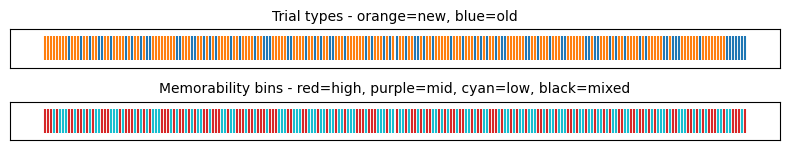

In [10]:
for task in ['task', 'task-mixed', 'task-matched']:

    print(f'\n================== Task: {task} ================== ')
    js_path = f'/Users/chrisiyer/_Current/lab/code/value-associability/episodic-choice-task/{task}/sequences/sequences.js'
    sequences = read_sequences_js(js_path)

    for seq in sequences:
        df = pd.DataFrame(seq['trials']).sort_values('trial_number').reset_index(drop=True)
        seed = seq['metadata'].get('seed', 'unknown')
        print(f'sequence/seed {seed}')
        check_old_new(df, task)
        check_old_conditions(df, task)
        check_values(df, task)
        check_delays(df, task)
        plot_sequences(df, task)